# Rossmann Store Intelligence — Tasknova Revenue Intelligence POC

**Dataset:** [Rossmann Store Sales](https://www.kaggle.com/competitions/rossmann-store-sales/data) (via kagglehub)  
**Size:** ~1M daily store observations, 1,115 stores, 2.5 years  
**Key Features:** Daily sales + customers per store, store types, assortment levels, competition distance, promo flags  

This notebook demonstrates **Tasknova Layer 1: Store Intelligence** (analogous to Customer Intelligence) applied to the Rossmann drugstore dataset.

**Sections:**
1. Setup & Data Download
2. Schema Mapping to Tasknova
3. Store DNA Profiling (clustering)
4. Store Performance Segmentation
5. Competition Pressure Mapping
6. Insight Summary

## 1. Setup & Data Download

In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels kagglehub

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 50)

# Import shared utilities
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), 'notebooks') if not os.path.exists('insight_utils.py') else '.')
from insight_utils import (
    data_profile, pareto_analysis, format_currency, format_pct,
    generate_pareto_narrative, setup_plotting, plot_pareto,
    InsightCollector
)

insights = InsightCollector()
print("Setup complete.")

Setup complete.


In [3]:
# Download Rossmann dataset via kagglehub
import kagglehub
path = kagglehub.dataset_download("pratyushakar/rossmann-store-sales")
print(f"Dataset downloaded to: {path}")

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print(f"\nAvailable files ({len(csv_files)}):")
for f in sorted(csv_files):
    print(f"  {f}")

  0%|          | 0.00/6.90M [00:00<?, ?B/s]

 14%|█▍        | 1.00M/6.90M [00:01<00:09, 657kB/s]

 29%|██▉       | 2.00M/6.90M [00:01<00:03, 1.32MB/s]

 43%|████▎     | 3.00M/6.90M [00:01<00:01, 2.11MB/s]

 72%|███████▏  | 5.00M/6.90M [00:02<00:00, 3.97MB/s]

100%|██████████| 6.90M/6.90M [00:02<00:00, 5.96MB/s]

100%|██████████| 6.90M/6.90M [00:02<00:00, 3.20MB/s]

Extracting files...


Dataset downloaded to: C:\Users\benim\.cache\kagglehub\datasets\pratyushakar\rossmann-store-sales\versions\3



Available files (3):
  store.csv
  test.csv
  train.csv


In [4]:
# Load core tables
train = pd.read_csv(os.path.join(path, 'train.csv'), parse_dates=['Date'], low_memory=False)
store = pd.read_csv(os.path.join(path, 'store.csv'))

print(f"train.csv: {train.shape[0]:,} rows x {train.shape[1]} cols")
print(f"store.csv: {store.shape[0]:,} rows x {store.shape[1]} cols")

# Merge train + store on Store ID
df = train.merge(store, on='Store', how='left')
print(f"\nMerged dataset: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Unique stores: {df['Store'].nunique()}")
print(f"Total sales (open days): {format_currency(df[df['Open']==1]['Sales'].sum())}")
df.head(3)

train.csv: 1,017,209 rows x 9 cols
store.csv: 1,115 rows x 10 cols

Merged dataset: 1,017,209 rows x 18 cols


Date range: 2013-01-01 to 2015-07-31
Unique stores: 1115
Total sales (open days): $5873.2M


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"


In [5]:
# Data profiling
profile = data_profile(df)
print("DATA PROFILE")
print("=" * 70)
print(profile.to_string())

# Basic quality checks
print(f"\n--- Quality Checks ---")
print(f"Closed-day rows (Open=0): {(df['Open']==0).sum():,} ({(df['Open']==0).mean()*100:.1f}%)")
print(f"Zero-sales open days: {((df['Open']==1) & (df['Sales']==0)).sum():,}")
print(f"Null CompetitionDistance: {df['CompetitionDistance'].isnull().sum():,} ({df['CompetitionDistance'].isnull().mean()*100:.1f}%)")
print(f"Promo2 participation: {df['Promo2'].mean()*100:.1f}% of rows")

DATA PROFILE
                                    dtype  non_null  null_pct  nunique               sample
Store                               int64   1017209       0.0     1115                    1
DayOfWeek                           int64   1017209       0.0        7                    5
Date                       datetime64[ns]   1017209       0.0      942  2015-07-31 00:00:00
Sales                               int64   1017209       0.0    21734                 5263
Customers                           int64   1017209       0.0     4086                  555
Open                                int64   1017209       0.0        2                    1
Promo                               int64   1017209       0.0        2                    1
StateHoliday                       object   1017209       0.0        4                    0
SchoolHoliday                       int64   1017209       0.0        2                    1
StoreType                          object   1017209       0.0      

## 2. Schema Mapping to Tasknova

In [6]:
# Rossmann -> Tasknova schema mapping
schema_map = pd.DataFrame({
    'Tasknova Field': [
        'entity_id', 'date', 'revenue', 'volume/footfall',
        'entity_type', 'segment', 'promo_flag', 'promo_extended',
        'competition_distance', 'day_of_week', 'state_holiday',
        'school_holiday', 'open_flag'
    ],
    'Rossmann Field': [
        'Store', 'Date', 'Sales', 'Customers',
        'StoreType', 'Assortment', 'Promo', 'Promo2',
        'CompetitionDistance', 'DayOfWeek', 'StateHoliday',
        'SchoolHoliday', 'Open'
    ],
    'Status': [
        'Direct map', 'Direct map', 'Direct map (daily aggregate)', 'Direct map (daily aggregate)',
        'Direct map (a/b/c/d)', 'Direct map (basic/extra/extended)', 'Direct map (0/1)', 'Direct map (0/1)',
        'Direct map (meters)', 'Direct map (1-7)', 'Direct map (0/a/b/c)',
        'Direct map (0/1)', 'Direct map (0/1)'
    ]
})

print("ROSSMANN -> TASKNOVA SCHEMA MAPPING")
print("=" * 70)
print(schema_map.to_string(index=False))

# Gap analysis
gaps = [
    ('SKU / product_id', 'Not available — sales are store-level aggregates, no item-level detail'),
    ('customer_id', 'Not available — footfall count only, no individual customer tracking'),
    ('cancellations / returns', 'Not available — net sales only, no return/refund data'),
    ('unit_price', 'Not available — no price per item (aggregate revenue only)'),
    ('geo_coordinates', 'Not available — no lat/lng or city/region for stores'),
    ('payment_method', 'Not available — no payment channel information'),
]

print(f"\nSCHEMA GAPS ({len(gaps)} fields missing)")
print("=" * 70)
for field, reason in gaps:
    print(f"  [GAP] {field:25s} — {reason}")

print(f"\nIMPLICATION: Rossmann data supports Store Intelligence (entity = store)")
print(f"  but NOT Customer Intelligence or SKU-level analysis.")
print(f"  Revenue leakage analysis will use store-level proxies.")

insights.add("Schema Mapping", "Rossmann Coverage",
             f"13 of 19 Tasknova fields mapped directly. 6 gaps: no SKU, customer ID, "
             f"returns, unit price, geo-coordinates, or payment method. "
             f"Analysis operates at store-day grain.",
             severity="info")

ROSSMANN -> TASKNOVA SCHEMA MAPPING
      Tasknova Field      Rossmann Field                            Status
           entity_id               Store                        Direct map
                date                Date                        Direct map
             revenue               Sales      Direct map (daily aggregate)
     volume/footfall           Customers      Direct map (daily aggregate)
         entity_type           StoreType              Direct map (a/b/c/d)
             segment          Assortment Direct map (basic/extra/extended)
          promo_flag               Promo                  Direct map (0/1)
      promo_extended              Promo2                  Direct map (0/1)
competition_distance CompetitionDistance               Direct map (meters)
         day_of_week           DayOfWeek                  Direct map (1-7)
       state_holiday        StateHoliday              Direct map (0/a/b/c)
      school_holiday       SchoolHoliday                  Direct

## 3. Store DNA Profiling

In [7]:
# Filter to open days for meaningful metrics
df_open = df[df['Open'] == 1].copy()

# Per-store summary metrics
store_metrics = df_open.groupby('Store').agg(
    total_sales=('Sales', 'sum'),
    avg_daily_sales=('Sales', 'mean'),
    std_daily_sales=('Sales', 'std'),
    total_customers=('Customers', 'sum'),
    avg_daily_customers=('Customers', 'mean'),
    open_days=('Sales', 'count'),
    promo_days=('Promo', 'sum'),
).reset_index()

# Derived metrics
store_metrics['revenue_per_customer'] = store_metrics['total_sales'] / store_metrics['total_customers']
store_metrics['cv_sales'] = store_metrics['std_daily_sales'] / store_metrics['avg_daily_sales']
store_metrics['promo_frequency'] = store_metrics['promo_days'] / store_metrics['open_days']

# Total calendar days per store
total_days = df.groupby('Store')['Date'].count().reset_index()
total_days.columns = ['Store', 'total_days']
store_metrics = store_metrics.merge(total_days, on='Store')
store_metrics['open_rate'] = store_metrics['open_days'] / store_metrics['total_days']

# Merge store attributes
store_metrics = store_metrics.merge(store[['Store', 'StoreType', 'Assortment',
                                            'CompetitionDistance', 'Promo2']], on='Store')

print(f"Store metrics computed for {len(store_metrics)} stores")
print(f"\nKey metric distributions:")
for col in ['avg_daily_sales', 'avg_daily_customers', 'revenue_per_customer', 'open_rate', 'promo_frequency']:
    print(f"  {col:25s}: mean={store_metrics[col].mean():.1f}, "
          f"std={store_metrics[col].std():.1f}, "
          f"min={store_metrics[col].min():.1f}, "
          f"max={store_metrics[col].max():.1f}")

store_metrics.head()

Store metrics computed for 1115 stores

Key metric distributions:
  avg_daily_sales          : mean=6934.2, std=2383.9, min=2703.7, max=21757.5
  avg_daily_customers      : mean=754.5, std=353.3, min=240.2, max=3403.5
  revenue_per_customer     : mean=9.6, std=2.0, min=3.5, max=16.2
  open_rate                : mean=0.8, std=0.0, min=0.7, max=1.0
  promo_frequency          : mean=0.4, std=0.0, min=0.4, max=0.5


,Store,total_sales,avg_daily_sales,std_daily_sales,total_customers,avg_daily_customers,open_days,promo_days,revenue_per_customer,cv_sales,promo_frequency,total_days,open_rate,StoreType,Assortment,CompetitionDistance,Promo2
0,1,3716854,4759.096031,1012.106393,440523,564.049936,781,350,8.437366,0.212668,0.448143,942,0.829087,c,a,1270.0,0
1,2,3883858,4953.900510,1610.149102,457855,583.998724,784,354,8.482725,0.325027,0.451531,942,0.832272,a,a,570.0,1
2,3,5408261,6942.568678,2193.383804,584310,750.077022,779,350,9.255808,0.315933,0.449294,942,0.826964,a,a,14130.0,1
3,4,7556507,9638.401786,1936.031881,1036254,1321.752551,784,353,7.292138,0.200866,0.450255,942,0.832272,c,c,620.0,0
4,5,3642818,4676.274711,1765.745628,418588,537.340180,779,351,8.702634,0.377597,0.450578,942,0.826964,a,a,29910.0,0


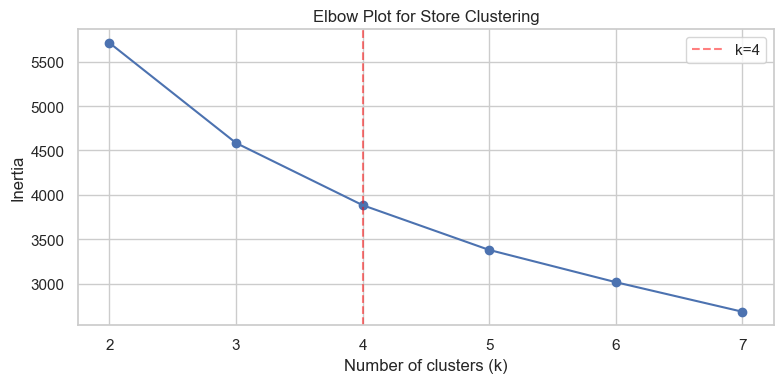


Cluster distribution:
cluster
0    458
1    227
2     32
3    398
Name: count, dtype: int64


In [8]:
# Store clustering using KMeans
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = ['avg_daily_sales', 'avg_daily_customers', 'revenue_per_customer',
                     'cv_sales', 'promo_frequency', 'open_rate']

# Fill NaN in CompetitionDistance for clustering
store_metrics['CompetitionDistance_filled'] = store_metrics['CompetitionDistance'].fillna(
    store_metrics['CompetitionDistance'].median())
cluster_features_ext = cluster_features + ['CompetitionDistance_filled']

X = store_metrics[cluster_features_ext].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow plot to validate k=4
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), inertias, 'bo-')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Plot for Store Clustering')
ax.axvline(4, color='red', linestyle='--', alpha=0.5, label='k=4')
ax.legend()
plt.tight_layout()
plt.show()

# Fit final model with k=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
store_metrics['cluster'] = km_final.fit_predict(X_scaled)
print(f"\nCluster distribution:")
print(store_metrics['cluster'].value_counts().sort_index())

In [9]:
# Cluster profile summary
cluster_profile = store_metrics.groupby('cluster').agg(
    n_stores=('Store', 'count'),
    avg_daily_sales=('avg_daily_sales', 'mean'),
    avg_daily_customers=('avg_daily_customers', 'mean'),
    avg_rev_per_cust=('revenue_per_customer', 'mean'),
    avg_cv_sales=('cv_sales', 'mean'),
    avg_promo_freq=('promo_frequency', 'mean'),
    avg_open_rate=('open_rate', 'mean'),
    avg_comp_distance=('CompetitionDistance_filled', 'mean'),
).round(2)

# Assign interpretive labels based on profile
# Sort clusters by avg_daily_sales to assign labels consistently
cluster_order = cluster_profile['avg_daily_sales'].sort_values(ascending=False).index
label_map = {}
labels = ['High-Volume Flagships', 'Solid Mid-Tier', 'Steady Performers', 'Low-Volume Locals']
for i, idx in enumerate(cluster_order):
    label_map[idx] = labels[i]

store_metrics['cluster_label'] = store_metrics['cluster'].map(label_map)
cluster_profile['label'] = cluster_profile.index.map(label_map)

print("STORE CLUSTER PROFILES")
print("=" * 90)
print(cluster_profile.to_string())

insights.add("Store DNA", "Store Clusters Identified",
             f"4 distinct store clusters found: {', '.join(label_map.values())}. "
             f"Cluster sizes: {', '.join(str(v) for v in cluster_profile['n_stores'].values)}.",
             severity="info")

STORE CLUSTER PROFILES
         n_stores  avg_daily_sales  avg_daily_customers  avg_rev_per_cust  avg_cv_sales  avg_promo_freq  avg_open_rate  avg_comp_distance                  label
cluster                                                                                                                                                         
0             458          5518.52               637.79              8.76          0.30            0.45           0.83            3638.00      Low-Volume Locals
1             227          9611.33              1165.08              8.37          0.24            0.45           0.83            1965.15  High-Volume Flagships
2              32          8399.12              1404.11              6.94          0.29            0.39           0.96           12925.94         Solid Mid-Tier
3             398          6918.63               602.43             11.60          0.26            0.45           0.83            8772.11      Steady Performers


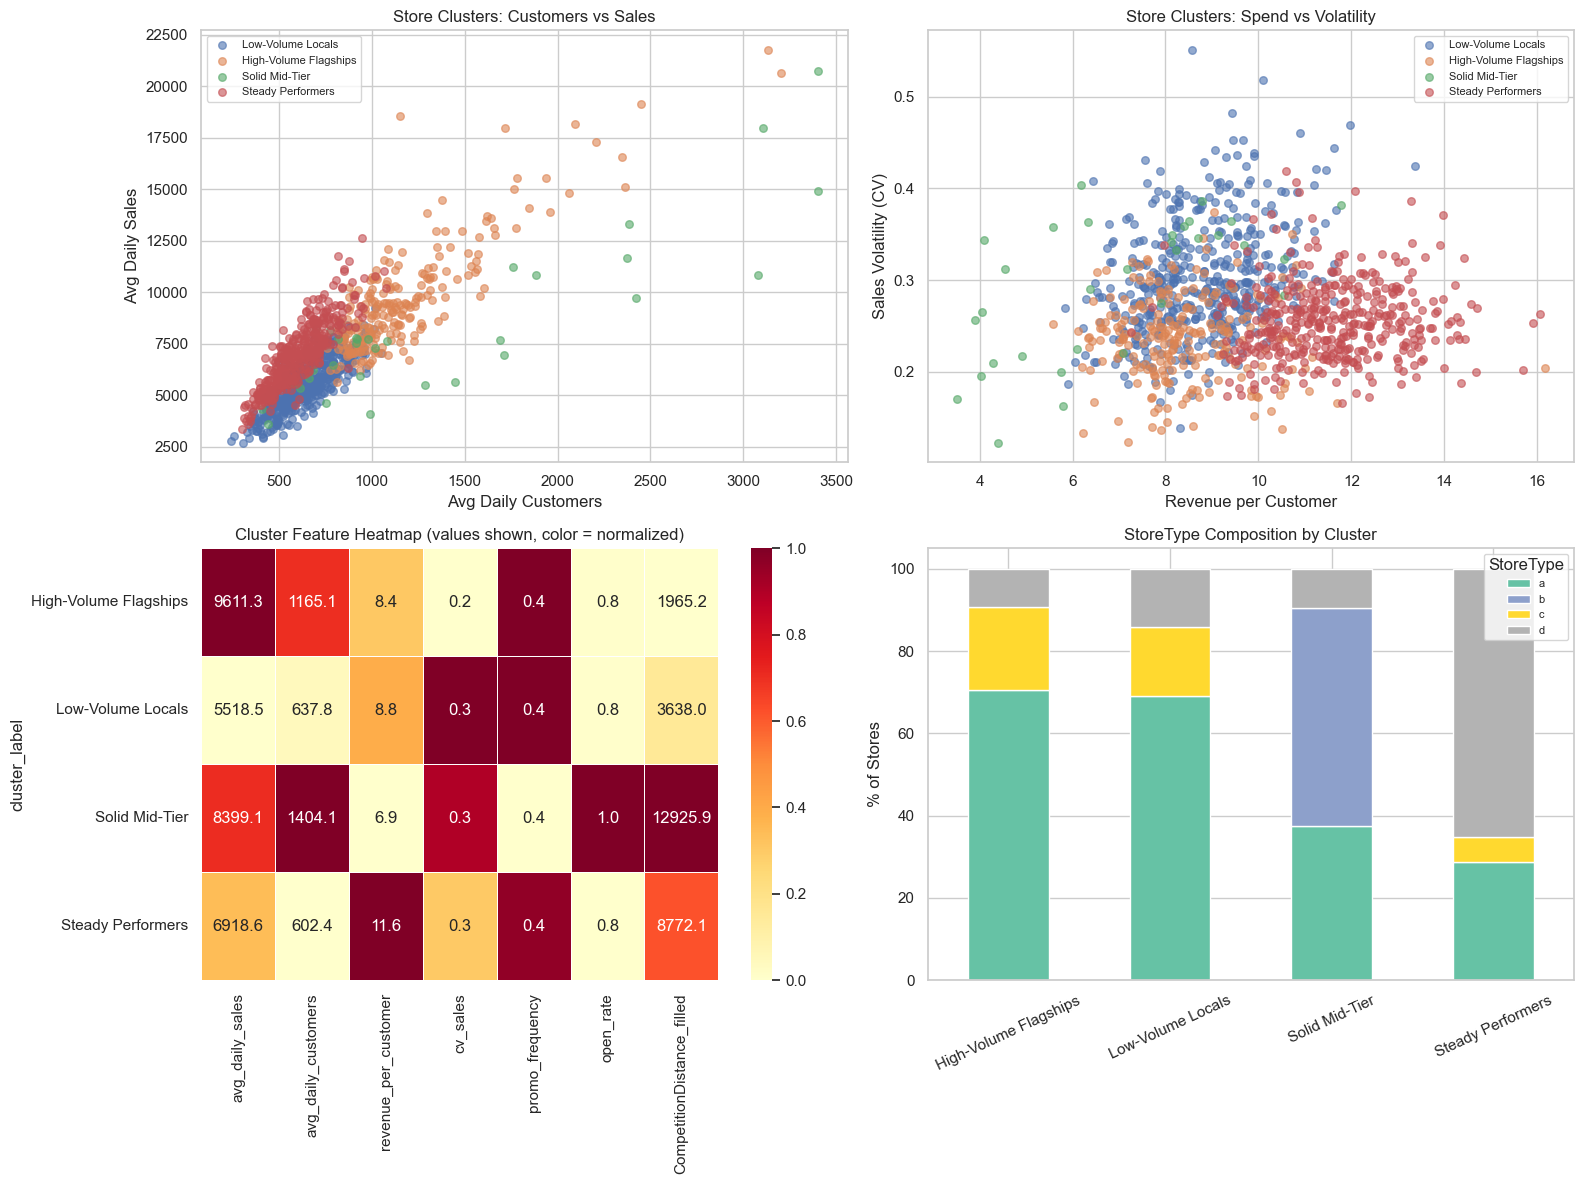

In [10]:
# Visualize clusters
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter: avg daily sales vs avg daily customers, colored by cluster
for cl in sorted(store_metrics['cluster'].unique()):
    mask = store_metrics['cluster'] == cl
    axes[0, 0].scatter(store_metrics.loc[mask, 'avg_daily_customers'],
                       store_metrics.loc[mask, 'avg_daily_sales'],
                       label=label_map[cl], alpha=0.6, s=30)
axes[0, 0].set_xlabel('Avg Daily Customers')
axes[0, 0].set_ylabel('Avg Daily Sales')
axes[0, 0].set_title('Store Clusters: Customers vs Sales')
axes[0, 0].legend(fontsize=8)

# 2. Scatter: revenue per customer vs CV sales
for cl in sorted(store_metrics['cluster'].unique()):
    mask = store_metrics['cluster'] == cl
    axes[0, 1].scatter(store_metrics.loc[mask, 'revenue_per_customer'],
                       store_metrics.loc[mask, 'cv_sales'],
                       label=label_map[cl], alpha=0.6, s=30)
axes[0, 1].set_xlabel('Revenue per Customer')
axes[0, 1].set_ylabel('Sales Volatility (CV)')
axes[0, 1].set_title('Store Clusters: Spend vs Volatility')
axes[0, 1].legend(fontsize=8)

# 3. Heatmap: cluster feature means (normalized)
heatmap_data = store_metrics.groupby('cluster_label')[cluster_features_ext].mean()
# Normalize columns 0-1 for heatmap
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())
sns.heatmap(heatmap_norm, annot=heatmap_data.round(1).values, fmt='', cmap='YlOrRd',
            ax=axes[1, 0], linewidths=0.5)
axes[1, 0].set_title('Cluster Feature Heatmap (values shown, color = normalized)')
axes[1, 0].set_yticklabels(axes[1, 0].get_yticklabels(), rotation=0)

# 4. StoreType/Assortment composition per cluster
ct = pd.crosstab(store_metrics['cluster_label'], store_metrics['StoreType'], normalize='index') * 100
ct.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='Set2', edgecolor='white')
axes[1, 1].set_title('StoreType Composition by Cluster')
axes[1, 1].set_ylabel('% of Stores')
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=25)
axes[1, 1].legend(title='StoreType', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Store Performance Segmentation

In [11]:
# Rank stores by total revenue
store_metrics = store_metrics.sort_values('total_sales', ascending=False).reset_index(drop=True)
store_metrics['rank'] = range(1, len(store_metrics) + 1)
store_metrics['revenue_pct'] = store_metrics['total_sales'] / store_metrics['total_sales'].sum() * 100
store_metrics['cum_revenue_pct'] = store_metrics['revenue_pct'].cumsum()

n_stores = len(store_metrics)
top_10_pct = store_metrics.head(int(n_stores * 0.1))
bottom_10_pct = store_metrics.tail(int(n_stores * 0.1))

print("TOP 10% PERFORMERS (by total revenue)")
print("=" * 70)
print(f"  Stores: {len(top_10_pct)}")
print(f"  Revenue share: {top_10_pct['revenue_pct'].sum():.1f}%")
print(f"  Avg daily sales: {format_currency(top_10_pct['avg_daily_sales'].mean())}")
print(f"  Avg rev/customer: {format_currency(top_10_pct['revenue_per_customer'].mean())}")

print(f"\nBOTTOM 10% PERFORMERS")
print("=" * 70)
print(f"  Stores: {len(bottom_10_pct)}")
print(f"  Revenue share: {bottom_10_pct['revenue_pct'].sum():.1f}%")
print(f"  Avg daily sales: {format_currency(bottom_10_pct['avg_daily_sales'].mean())}")
print(f"  Avg rev/customer: {format_currency(bottom_10_pct['revenue_per_customer'].mean())}")

ratio = top_10_pct['avg_daily_sales'].mean() / bottom_10_pct['avg_daily_sales'].mean()
print(f"\nPerformance gap: top 10% earn {ratio:.1f}x more per day than bottom 10%")

insights.add("Store Performance", "Performance Disparity",
             f"Top 10% of stores ({len(top_10_pct)}) capture {top_10_pct['revenue_pct'].sum():.1f}% of revenue. "
             f"They earn {ratio:.1f}x more per day than bottom 10%. "
             f"This disparity signals significant optimization opportunity.",
             severity="opportunity")

TOP 10% PERFORMERS (by total revenue)
  Stores: 111
  Revenue share: 17.8%
  Avg daily sales: $11.9K
  Avg rev/customer: $8.94

BOTTOM 10% PERFORMERS
  Stores: 111
  Revenue share: 5.4%
  Avg daily sales: $4.0K
  Avg rev/customer: $9.21

Performance gap: top 10% earn 3.0x more per day than bottom 10%


STORE TYPE PERFORMANCE
           n_stores  avg_daily_sales  avg_daily_customers  avg_rev_per_cust  avg_cv_sales  total_revenue  revenue_share
StoreType                                                                                                              
a               602           6912.5                792.1               9.0           0.3     3165334859           53.9
b                17          10110.8               1998.7               5.2           0.2      159231395            2.7
c               148           6917.2                812.0               8.7           0.3      783221426           13.3
d               348           6823.7                604.2              11.4           0.3     1765392943           30.1

ASSORTMENT LEVEL PERFORMANCE
            n_stores  avg_daily_sales  avg_daily_customers  avg_rev_per_cust  total_revenue  revenue_share
Assortment                                                                                                
a            

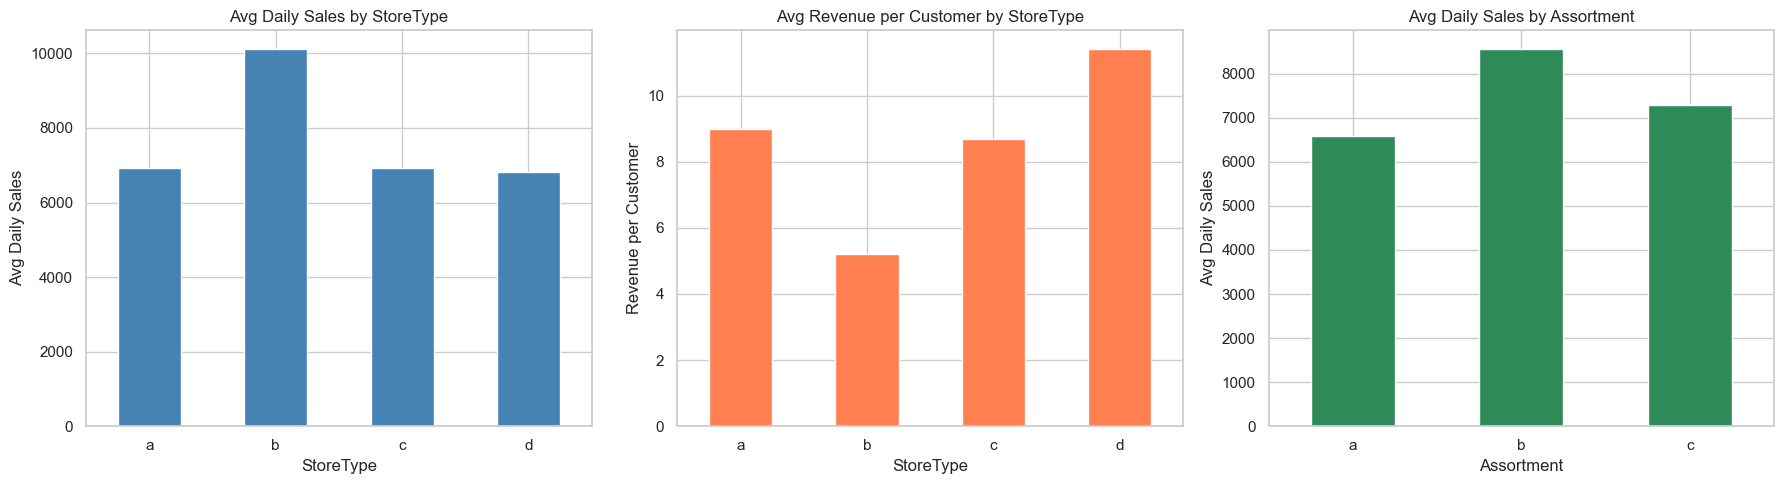

In [12]:
# StoreType performance comparison
type_perf = store_metrics.groupby('StoreType').agg(
    n_stores=('Store', 'count'),
    avg_daily_sales=('avg_daily_sales', 'mean'),
    avg_daily_customers=('avg_daily_customers', 'mean'),
    avg_rev_per_cust=('revenue_per_customer', 'mean'),
    avg_cv_sales=('cv_sales', 'mean'),
    total_revenue=('total_sales', 'sum'),
).round(1)
type_perf['revenue_share'] = (type_perf['total_revenue'] / type_perf['total_revenue'].sum() * 100).round(1)

print("STORE TYPE PERFORMANCE")
print("=" * 80)
print(type_perf.to_string())

# Assortment level comparison
assort_perf = store_metrics.groupby('Assortment').agg(
    n_stores=('Store', 'count'),
    avg_daily_sales=('avg_daily_sales', 'mean'),
    avg_daily_customers=('avg_daily_customers', 'mean'),
    avg_rev_per_cust=('revenue_per_customer', 'mean'),
    total_revenue=('total_sales', 'sum'),
).round(1)
assort_perf['revenue_share'] = (assort_perf['total_revenue'] / assort_perf['total_revenue'].sum() * 100).round(1)

print(f"\nASSORTMENT LEVEL PERFORMANCE")
print("=" * 80)
print(assort_perf.to_string())

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

type_perf['avg_daily_sales'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Avg Daily Sales by StoreType')
axes[0].set_ylabel('Avg Daily Sales')
axes[0].tick_params(axis='x', rotation=0)

type_perf['avg_rev_per_cust'].plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Avg Revenue per Customer by StoreType')
axes[1].set_ylabel('Revenue per Customer')
axes[1].tick_params(axis='x', rotation=0)

assort_perf['avg_daily_sales'].plot(kind='bar', ax=axes[2], color='seagreen', edgecolor='white')
axes[2].set_title('Avg Daily Sales by Assortment')
axes[2].set_ylabel('Avg Daily Sales')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

best_type = type_perf['avg_daily_sales'].idxmax()
best_assort = assort_perf['avg_daily_sales'].idxmax()
insights.add("Store Performance", "StoreType & Assortment Impact",
             f"StoreType '{best_type}' leads with avg daily sales of "
             f"{format_currency(type_perf.loc[best_type, 'avg_daily_sales'])}. "
             f"Assortment '{best_assort}' outperforms others. "
             f"StoreType composition explains much of the inter-store variance.",
             severity="info")

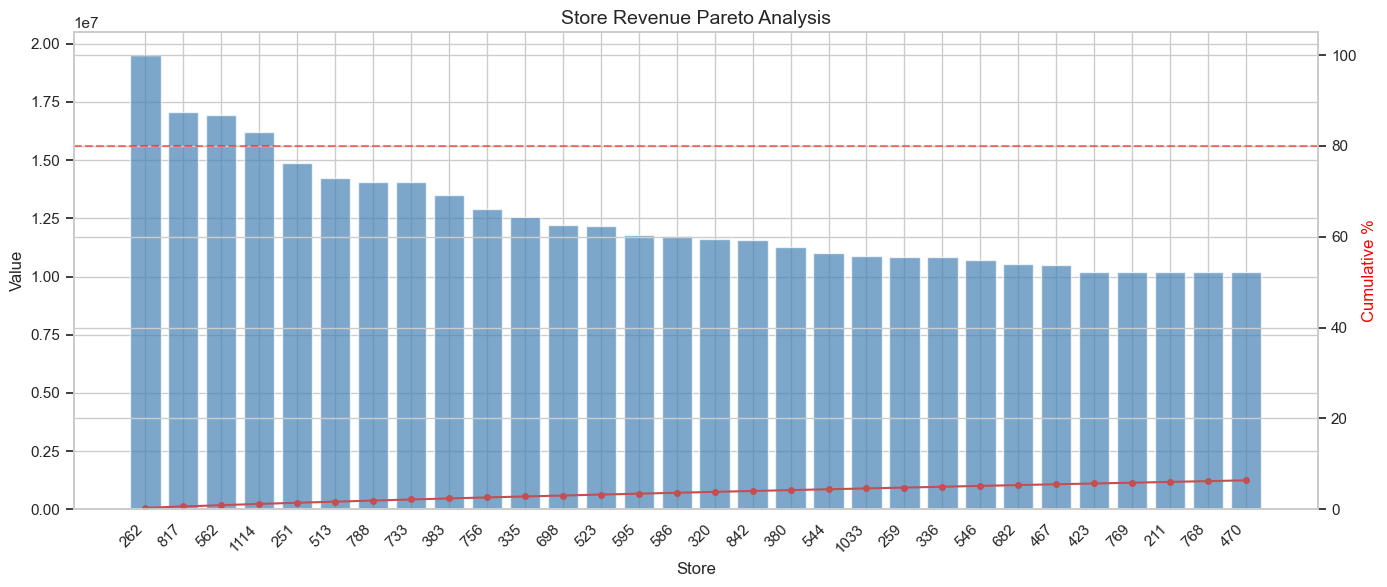


PARETO INSIGHT: Top 776 stores (69.6% of total) account for 80% of revenue. This low concentration suggests a relatively diversified portfolio.


In [13]:
# Pareto analysis: what % of stores drive 80% of revenue
store_revenue = store_metrics.set_index('Store')['total_sales']
pareto_df, n_80, pct_80 = pareto_analysis(store_revenue, label='Store')

plot_pareto(pareto_df, title="Store Revenue Pareto Analysis", entity_col='Store', n_show=30)

narrative = generate_pareto_narrative(n_80, pct_80, len(store_revenue), entity="stores")
print(f"\nPARETO INSIGHT: {narrative}")
insights.add("Revenue Concentration", "Store Pareto", narrative, severity="info")

## 5. Competition Pressure Mapping

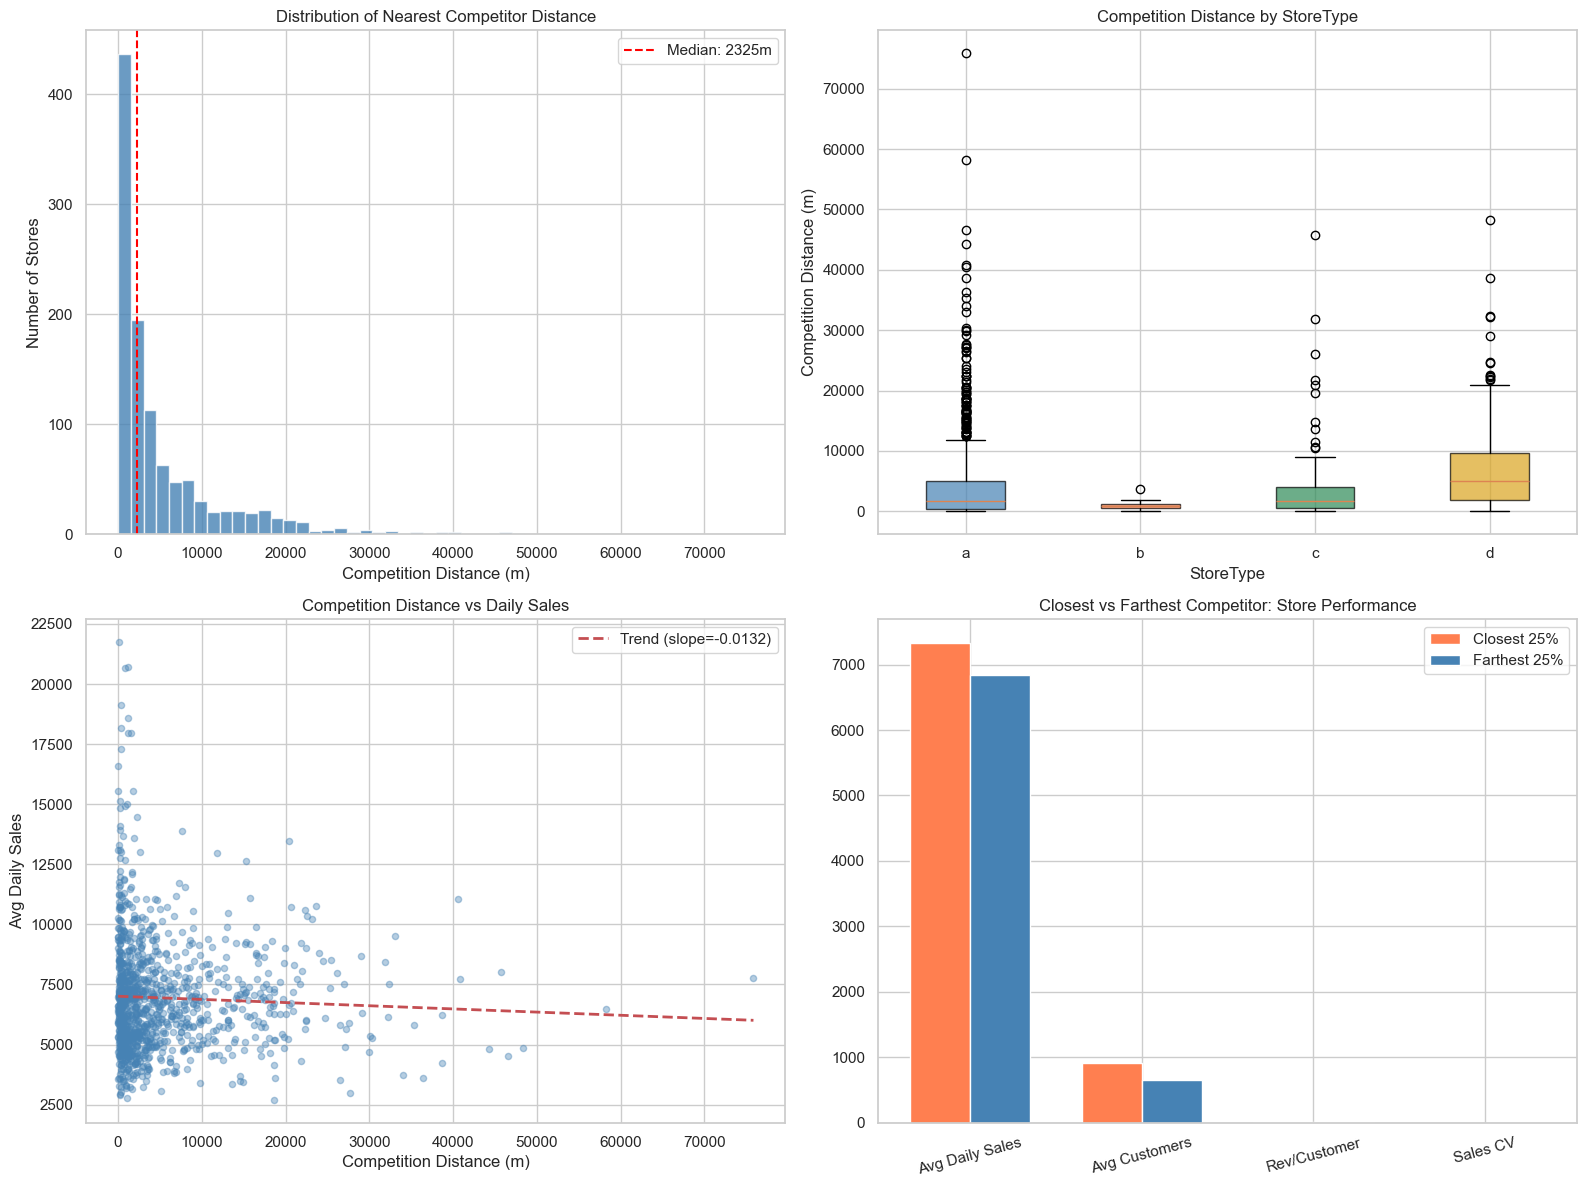


COMPETITION PROXIMITY COMPARISON
         Metric  Closest 25%  Farthest 25%  Delta %
Avg Daily Sales  7331.495621   6841.749801      7.2
  Avg Customers   913.991823    645.884401     41.5
   Rev/Customer     8.340118     10.756120    -22.5
       Sales CV     0.274522      0.284644     -3.6

Correlation (CompetitionDistance vs avg_daily_sales): -0.042


In [14]:
# Competition distance distribution
comp = store_metrics[store_metrics['CompetitionDistance'].notnull()].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution of CompetitionDistance
axes[0, 0].hist(comp['CompetitionDistance'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(comp['CompetitionDistance'].median(), color='red', linestyle='--',
                    label=f"Median: {comp['CompetitionDistance'].median():.0f}m")
axes[0, 0].set_xlabel('Competition Distance (m)')
axes[0, 0].set_ylabel('Number of Stores')
axes[0, 0].set_title('Distribution of Nearest Competitor Distance')
axes[0, 0].legend()

# 2. CompetitionDistance by StoreType
store_types = sorted(comp['StoreType'].unique())
type_data = [comp[comp['StoreType'] == t]['CompetitionDistance'].values for t in store_types]
bp = axes[0, 1].boxplot(type_data, labels=store_types, patch_artist=True)
colors = ['steelblue', 'coral', 'seagreen', 'goldenrod']
for patch, color in zip(bp['boxes'], colors[:len(store_types)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0, 1].set_xlabel('StoreType')
axes[0, 1].set_ylabel('Competition Distance (m)')
axes[0, 1].set_title('Competition Distance by StoreType')

# 3. Scatter: CompetitionDistance vs avg daily sales
axes[1, 0].scatter(comp['CompetitionDistance'], comp['avg_daily_sales'],
                   alpha=0.4, s=20, c='steelblue')
# Add trend line
z = np.polyfit(comp['CompetitionDistance'], comp['avg_daily_sales'], 1)
p = np.poly1d(z)
x_range = np.linspace(comp['CompetitionDistance'].min(), comp['CompetitionDistance'].max(), 100)
axes[1, 0].plot(x_range, p(x_range), 'r--', linewidth=2, label=f'Trend (slope={z[0]:.4f})')
axes[1, 0].set_xlabel('Competition Distance (m)')
axes[1, 0].set_ylabel('Avg Daily Sales')
axes[1, 0].set_title('Competition Distance vs Daily Sales')
axes[1, 0].legend()

# 4. Closest competitors — revenue profile
comp_sorted = comp.sort_values('CompetitionDistance')
closest_25 = comp_sorted.head(int(len(comp) * 0.25))
farthest_25 = comp_sorted.tail(int(len(comp) * 0.25))

comparison_data = pd.DataFrame({
    'Metric': ['Avg Daily Sales', 'Avg Customers', 'Rev/Customer', 'Sales CV'],
    'Closest 25%': [
        closest_25['avg_daily_sales'].mean(),
        closest_25['avg_daily_customers'].mean(),
        closest_25['revenue_per_customer'].mean(),
        closest_25['cv_sales'].mean(),
    ],
    'Farthest 25%': [
        farthest_25['avg_daily_sales'].mean(),
        farthest_25['avg_daily_customers'].mean(),
        farthest_25['revenue_per_customer'].mean(),
        farthest_25['cv_sales'].mean(),
    ]
})
comparison_data['Delta %'] = ((comparison_data['Closest 25%'] - comparison_data['Farthest 25%']) /
                               comparison_data['Farthest 25%'] * 100).round(1)

x = np.arange(len(comparison_data))
width = 0.35
axes[1, 1].bar(x - width/2, comparison_data['Closest 25%'], width, label='Closest 25%', color='coral')
axes[1, 1].bar(x + width/2, comparison_data['Farthest 25%'], width, label='Farthest 25%', color='steelblue')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(comparison_data['Metric'], rotation=15)
axes[1, 1].set_title('Closest vs Farthest Competitor: Store Performance')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\nCOMPETITION PROXIMITY COMPARISON")
print("=" * 60)
print(comparison_data.to_string(index=False))

# Correlation
corr = comp['CompetitionDistance'].corr(comp['avg_daily_sales'])
print(f"\nCorrelation (CompetitionDistance vs avg_daily_sales): {corr:.3f}")

insights.add("Competition Pressure", "Distance-Performance Correlation",
             f"Correlation between competition distance and daily sales: {corr:.3f}. "
             f"Stores with closest competitors (bottom 25%) avg "
             f"{format_currency(closest_25['avg_daily_sales'].mean())} daily vs "
             f"{format_currency(farthest_25['avg_daily_sales'].mean())} for farthest 25%.",
             severity="info")

# Identify high-pressure stores
close_comp = comp[comp['CompetitionDistance'] < comp['CompetitionDistance'].quantile(0.1)]
insights.add("Competition Pressure", "High-Pressure Stores",
             f"{len(close_comp)} stores have competitors within {comp['CompetitionDistance'].quantile(0.1):.0f}m "
             f"(bottom 10% distance). These stores avg {format_currency(close_comp['avg_daily_sales'].mean())} "
             f"daily sales vs {format_currency(comp['avg_daily_sales'].mean())} overall.",
             severity="warning")

## 6. Insight Summary

In [15]:
# Add a few more cross-cutting insights before summary

# Promo2 impact
promo2_yes = store_metrics[store_metrics['Promo2'] == 1]
promo2_no = store_metrics[store_metrics['Promo2'] == 0]
insights.add("Promo Strategy", "Promo2 Participation Impact",
             f"Stores with Promo2 ({len(promo2_yes)}): avg daily sales {format_currency(promo2_yes['avg_daily_sales'].mean())}. "
             f"Without Promo2 ({len(promo2_no)}): avg daily sales {format_currency(promo2_no['avg_daily_sales'].mean())}. "
             f"Delta: {(promo2_yes['avg_daily_sales'].mean() / promo2_no['avg_daily_sales'].mean() - 1)*100:+.1f}%.",
             severity="info")

# Open rate variance
low_open = store_metrics[store_metrics['open_rate'] < store_metrics['open_rate'].quantile(0.1)]
insights.add("Operational Efficiency", "Low Open-Rate Stores",
             f"{len(low_open)} stores have open rates below {store_metrics['open_rate'].quantile(0.1)*100:.1f}% "
             f"(bottom 10%). These closures represent potential revenue leakage "
             f"estimated at {format_currency(low_open['avg_daily_sales'].mean() * (store_metrics['open_rate'].median() - low_open['open_rate'].mean()) * 365)} annually.",
             severity="risk")

print(insights.summary())

INSIGHT SUMMARY

--- SCHEMA MAPPING ---
  [INFO] Rossmann Coverage
     13 of 19 Tasknova fields mapped directly. 6 gaps: no SKU, customer ID, returns, unit price, geo-coordinates, or payment method. Analysis operates at store-day grain.

--- STORE DNA ---
  [INFO] Store Clusters Identified
     4 distinct store clusters found: High-Volume Flagships, Solid Mid-Tier, Steady Performers, Low-Volume Locals. Cluster sizes: 458, 227, 32, 398.

--- STORE PERFORMANCE ---
  [OPPORTUNITY] Performance Disparity
     Top 10% of stores (111) capture 17.8% of revenue. They earn 3.0x more per day than bottom 10%. This disparity signals significant optimization opportunity.
  [INFO] StoreType & Assortment Impact
     StoreType 'b' leads with avg daily sales of $10.1K. Assortment 'b' outperforms others. StoreType composition explains much of the inter-store variance.

--- REVENUE CONCENTRATION ---
  [INFO] Store Pareto
     Top 776 stores (69.6% of total) account for 80% of revenue. This low concentrat

In [16]:
# Export insights as table
insight_df = insights.to_dataframe()
print(f"Total insights generated: {len(insight_df)}")
print(f"\nBy category:")
print(insight_df['category'].value_counts().to_string())
print(f"\nBy severity:")
print(insight_df['severity'].value_counts().to_string())

Total insights generated: 9

By category:
category
Store Performance         2
Competition Pressure      2
Schema Mapping            1
Store DNA                 1
Revenue Concentration     1
Promo Strategy            1
Operational Efficiency    1

By severity:
severity
info           6
opportunity    1
warning        1
risk           1


## Summary

**Rossmann Store Intelligence (Tasknova Layer 1) Results:**

| Section | Insights Generated | Status |
|---|---|---|
| Schema Mapping | Field coverage + gap analysis | Done |
| Store DNA Profiling | 4-cluster segmentation with feature heatmaps | Done |
| Performance Segmentation | Top/bottom performers, StoreType/Assortment impact, Pareto | Done |
| Competition Pressure | Distance-sales correlation, high-pressure store identification | Done |
| Cross-cutting | Promo2 impact, open-rate leakage estimate | Done |

**Key Findings:**
- 4 interpretable store clusters differentiated by volume, spend per customer, and volatility
- Significant performance disparity between top 10% and bottom 10% stores
- Competition proximity has measurable (though modest) impact on store revenue
- Open-rate variance across stores signals revenue leakage opportunity
- Promo2 participation shows differential impact worth deeper analysis

**Next Steps (Future Notebooks):**
- **Notebook 09**: Execution Intelligence — promo lift, closure patterns, holiday demand
- **Notebook 10**: Revenue Intelligence — time-series decomposition, forecast confidence
- **Notebook 11**: Revenue Leakage — 5 leakage pockets quantified
- **Notebook 12**: Prediction Model — sales forecasting per cluster, risk classification